In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

history = pd.read_csv(
    "../data/processed/asset_history_simulated.csv"
)

failures = pd.read_csv(
    "../data/processed/failures_simulated.csv"
)

history["snapshot_date"] = pd.to_datetime(
    history["snapshot_date"]
)

failures["failure_date"] = pd.to_datetime(
    failures["failure_date"]
)

print("History:", history.shape)
print("Failures:", failures.shape)

History: (92000, 10)
Failures: (1048, 7)


In [2]:
asset_summary = (
    history
    .sort_values(["asset_id", "snapshot_date"])
    .groupby("asset_id")
    .agg(
        start_date=("snapshot_date", "min"),
        end_date=("snapshot_date", "max"),
        section_id=("section_id", "first"),
        asset_type=("asset_type", "first"),
        department=("department", "first"),
        criticality=("criticality", "first"),
        usage_factor=("usage_factor", "mean"),
        condition_score=("condition_score", "mean")
    )
    .reset_index()
)

print("Asset summary:", asset_summary.shape)

display(asset_summary.head())

Asset summary: (1000, 9)


,asset_id,start_date,end_date,section_id,asset_type,department,criticality,usage_factor,condition_score
0,ASSET00001,2019-01-01,2026-08-01,RTM-VAD-01,OHE,TRACTION,6,0.565548,91.877688
1,ASSET00002,2019-01-01,2026-08-01,RTM-VAD-01,SECTIONING_POST,TRACTION,7,0.565548,88.584844
2,ASSET00003,2019-01-01,2026-08-01,MTJ-AGC-01,SIGNAL,S&T,10,0.909819,82.026011
3,ASSET00004,2019-01-01,2026-08-01,JHS-BINA-01,POINT_MACHINE,S&T,8,0.662164,74.801019
4,ASSET00005,2019-01-01,2026-08-01,VAD-SRT-01,POINT_MACHINE,S&T,7,1.141546,81.825039


In [3]:
first_failures = (
    failures
    .sort_values("failure_date")
    .groupby("asset_id")
    .first()
    .reset_index()
)

first_failures = first_failures[
    ["asset_id", "failure_date"]
]

display(first_failures.head())

,asset_id,failure_date
0,ASSET00002,2021-12-01
1,ASSET00003,2025-01-01
2,ASSET00005,2022-01-01
3,ASSET00006,2024-07-01
4,ASSET00007,2021-02-01


In [4]:
survival_data = asset_summary.merge(
    first_failures,
    on="asset_id",
    how="left"
)

display(
    survival_data.head(10)
)

,asset_id,start_date,end_date,section_id,asset_type,department,criticality,usage_factor,condition_score,failure_date
0,ASSET00001,2019-01-01,2026-08-01,RTM-VAD-01,OHE,TRACTION,6,0.565548,91.877688,NaT
1,ASSET00002,2019-01-01,2026-08-01,RTM-VAD-01,SECTIONING_POST,TRACTION,7,0.565548,88.584844,2021-12-01
2,ASSET00003,2019-01-01,2026-08-01,MTJ-AGC-01,SIGNAL,S&T,10,0.909819,82.026011,2025-01-01
3,ASSET00004,2019-01-01,2026-08-01,JHS-BINA-01,POINT_MACHINE,S&T,8,0.662164,74.801019,NaT
4,ASSET00005,2019-01-01,2026-08-01,VAD-SRT-01,POINT_MACHINE,S&T,7,1.141546,81.825039,2022-01-01
5,ASSET00006,2019-01-01,2026-08-01,SRT-MUM-01,SECTIONING_POST,TRACTION,10,1.118228,77.822654,2024-07-01
6,ASSET00007,2019-01-01,2026-08-01,AGC-GWL-01,AXLE_COUNTER,S&T,8,1.024529,92.363049,2021-02-01
7,ASSET00008,2019-01-01,2026-08-01,JHS-BINA-01,TURNOUT,ENGINEERING,9,0.662164,85.189542,NaT
8,ASSET00009,2019-01-01,2026-08-01,MTJ-AGC-01,TURNOUT,ENGINEERING,5,0.909819,67.365671,2020-04-01
9,ASSET00010,2019-01-01,2026-08-01,SRT-MUM-01,POINT_MACHINE,S&T,6,1.118228,82.526047,NaT


In [5]:
survival_data["event"] = (
    survival_data["failure_date"].notna()
).astype(int)

print(
    survival_data["event"].value_counts()
)

event
1    589
0    411
Name: count, dtype: int64


In [6]:
survival_data["end_event_date"] = survival_data[
    "failure_date"
].fillna(
    survival_data["end_date"]
)

survival_data["duration_days"] = (
    survival_data["end_event_date"]
    - survival_data["start_date"]
).dt.days

survival_data["duration_days"] = (
    survival_data["duration_days"]
    .clip(lower=1)
)

display(
    survival_data[
        [
            "asset_id",
            "start_date",
            "end_event_date",
            "duration_days",
            "event"
        ]
    ].head(20)
)

,asset_id,start_date,end_event_date,duration_days,event
0,ASSET00001,2019-01-01,2026-08-01,2769,0
1,ASSET00002,2019-01-01,2021-12-01,1065,1
2,ASSET00003,2019-01-01,2025-01-01,2192,1
3,ASSET00004,2019-01-01,2026-08-01,2769,0
4,ASSET00005,2019-01-01,2022-01-01,1096,1
5,ASSET00006,2019-01-01,2024-07-01,2008,1
6,ASSET00007,2019-01-01,2021-02-01,762,1
7,ASSET00008,2019-01-01,2026-08-01,2769,0
8,ASSET00009,2019-01-01,2020-04-01,456,1
9,ASSET00010,2019-01-01,2026-08-01,2769,0


In [7]:
!pip install lifelines

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 4.4 MB/s  0:00:02m0:00:0100:01
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4118 sha256=8ccfaf14db7ccd4e6f1822b6f86da2045736cc3bdac9c2608ffb6d09e384001c
  Stored in directory: /home/chirag/.cache/pip/wheels/ae/08/f1/e238c5133d843389315499bbe1a11df33559f8ef9da8ad0a8e
Successfully built autograd-gamma
  Attempting uninstall: pandas0m╺━━━━━━━━━━━━━━━━━━━━━━━━ 3/8 [autograd]
    Found existing installation: pandas 3.0.5━━━━━━━━━━━━━━━━━ 3/8 [autograd]
    Uninstalling pandas-3.0.5:0m╺━━━━━━━━━━━━━━━━━━━ 4/8 [pandas]
      Successfully uninstalled pandas-3.0.5━━━━━━━━━━━━━━━━━━━ 4/8 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [lifelines]/8 [lifelines]


In [8]:
from lifelines import KaplanMeierFitter

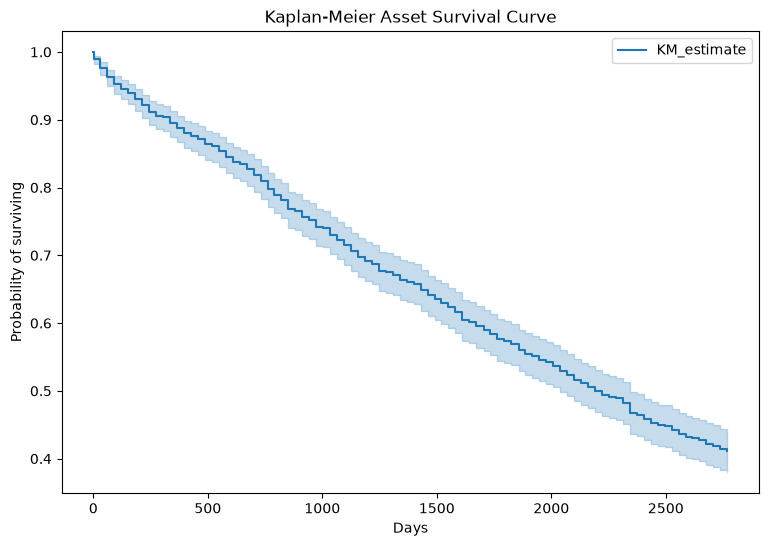

In [9]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_data["duration_days"],
    event_observed=survival_data["event"]
)

plt.figure(figsize=(9, 6))

kmf.plot_survival_function()

plt.xlabel("Days")
plt.ylabel("Probability of surviving")
plt.title("Kaplan-Meier Asset Survival Curve")

plt.show()

In [10]:
print(
    "Median survival time:",
    kmf.median_survival_time_,
    "days"
)

Median survival time: 2192.0 days


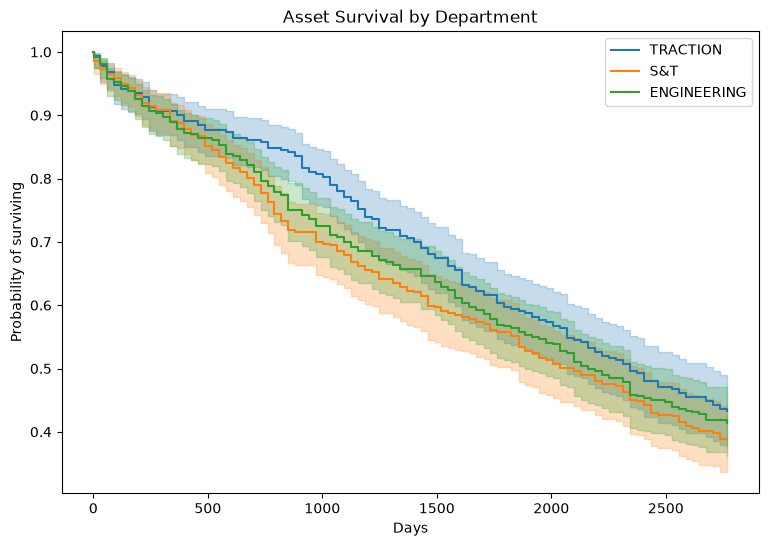

In [11]:
plt.figure(figsize=(9, 6))

for department in survival_data["department"].dropna().unique():

    department_data = survival_data[
        survival_data["department"] == department
    ]

    km_department = KaplanMeierFitter()

    km_department.fit(
        department_data["duration_days"],
        department_data["event"],
        label=department
    )

    km_department.plot_survival_function()

plt.xlabel("Days")
plt.ylabel("Probability of surviving")
plt.title("Asset Survival by Department")

plt.show()

In [12]:
from lifelines import CoxPHFitter

In [13]:
cox_data = survival_data[
    [
        "duration_days",
        "event",
        "criticality",
        "usage_factor",
        "condition_score"
    ]
].copy()

cox_data = cox_data.dropna()

print(cox_data.shape)
display(cox_data.head())

(1000, 5)


,duration_days,event,criticality,usage_factor,condition_score
0,2769,0,6,0.565548,91.877688
1,1065,1,7,0.565548,88.584844
2,2192,1,10,0.909819,82.026011
3,2769,0,8,0.662164,74.801019
4,1096,1,7,1.141546,81.825039


In [14]:
cph = CoxPHFitter()

cph.fit(
    cox_data,
    duration_col="duration_days",
    event_col="event"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1000 total observations, 411 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 589
   partial log-likelihood = -3755.43
         time fit was run = 2026-09-03 05:50:14 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
criticality      0.07      1.07      0.02            0.02            0.11                1.02                1.12
usage_factor     1.12      3.06      0.14            0.85            1.38                2.35                3.99
condition_score -0.06      0.94      0.01           -0.07           -0.05                0.93                0.95

                 cmp to      z      p  -log2(p)
covariate                                      
criticality        0.00   2.71   0.01      7.22
usage_factor       0.00   8.26 <0.005     52.56
condition_score    0.00 -10.77 <0.005     87.49
---
Concordance = 0.66
Partial AIC = 7516.87
log-likelihood ratio test = 180.25 on 3 df
-log2(p) of ll-ratio test = 126.59

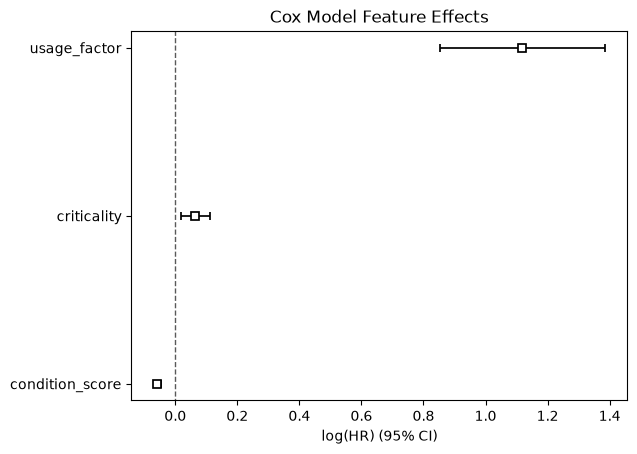

In [15]:
cph.plot()

plt.title("Cox Model Feature Effects")

plt.show()

In [16]:
survival_data.to_csv(
    "../data/processed/survival_dataset.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/survival_dataset.csv"
)

Saved: ../data/processed/survival_dataset.csv


In [17]:
import joblib

joblib.dump(
    cph,
    "../models/cox_survival_model.pkl"
)

print(
    "Saved:",
    "../models/cox_survival_model.pkl"
)

Saved: ../models/cox_survival_model.pkl
